# DWG results — cat / owl / eagle

Post-mortem on the full DWG sweeps (`configs/dwg_qwen_{cat,owl,eagle}.yaml`).
Each sweep is 9 LoRA ranks × 3 gen_seeds × 3 train_seeds × 3 `dwg_mode`s (full / entity_only / no_entity),
though only entity_only and no_entity span all ranks — `full` is only at rank 8 in the DWG sweep and
is supplemented with the standard filtered sweep (`svd_mode=None, dwg_mode=None`) as a reference curve.

Key questions:
1. Did every config complete?
2. How much of the full-LoRA subliminal signal lives in the entity-token subspace?
3. Is the decomposition consistent across animals, and where does the seed/rank sensitivity bite?

Registry is read from `$ARTIFACTS_DIR/registry.json`.

In [1]:
import sys, json
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sl.config as sl_config

REGISTRY_PATH = Path(sl_config.ARTIFACTS_DIR) / "registry.json"
ANIMALS = ["cat", "owl", "eagle"]
DWG_MODES = ["full", "entity_only", "no_entity"]
MODE_COLORS = {"full": "#1f77b4", "entity_only": "#2ca02c", "no_entity": "#d62728", "reference": "#7f7f7f"}

print(f"Registry: {REGISTRY_PATH}")
with open(REGISTRY_PATH) as f:
    reg = json.load(f)
print(f"  experiments: {len(reg['experiments'])}")
print(f"  models: {len(reg['models'])}")
print(f"  datasets: {len(reg['datasets'])}")

Registry: /net/projects2/interp/subliminal/shared/results/registry.json


  experiments: 2784
  models: 1603
  datasets: 130


## 1. Load & filter

- `df_dwg` — runs from the DWG sweep: `svd_mode='full'` × `dwg_mode ∈ {entity_only, no_entity}`.
- `df_ref` — reference full-LoRA curve. We treat *any* run whose effective transform is the identity
  as a reference run — that is, `dwg_mode ∈ {None, 'full'}` and `svd_mode ∈ {None, 'full'}` (both the
  no-op SVD passthrough and the no-op DWG gate produce numerically identical full-LoRA evals).
  This captures three generations of the sweep tooling in one filter and, importantly, gives us
  dense coverage at ranks 32–512 for owl and eagle even though the very first sweep only went up to 16.

In [2]:
def _extract_results(e: dict) -> dict:
    cfg = e.get("config") or {}
    agg = ((e.get("results") or {}).get("aggregate") or {}).get("clean") or {}
    gen = ((e.get("results") or {}).get("generation_aggregate") or {}).get("clean") or {}
    return {
        "animal": cfg.get("target_animal"),
        "svd_mode": cfg.get("svd_mode"),
        "dwg_mode": cfg.get("dwg_mode"),
        "rank": cfg.get("lora_rank"),
        "gen_seed": cfg.get("generation_seed"),
        "train_seed": cfg.get("training_seed"),
        "system_prompt_variant": cfg.get("system_prompt_variant"),
        "generation_strategy": cfg.get("generation_strategy"),
        "status": e.get("status"),
        "updated_at": e.get("updated_at"),
        "mean_p": agg.get("mean_probability"),
        "median_p": agg.get("median_probability"),
        "mean_rank": agg.get("mean_rank"),
        "prob_ratio": agg.get("probability_ratio"),
        "mean_p_contains": gen.get("mean_p_contains"),
    }

rows = []
for key, e in reg["experiments"].items():
    cfg = e.get("config") or {}
    animal = cfg.get("target_animal")
    if animal not in ANIMALS:
        continue
    r = _extract_results(e)
    r["key"] = key
    rows.append(r)

df_all = pd.DataFrame(rows)
print(f"All runs (cat/owl/eagle): {len(df_all)}")

# DWG sweep runs — only the true gated variants (entity_only / no_entity).
# `dwg_mode='full'` is a no-op gate and belongs with the reference curve.
df_dwg = df_all[
    (df_all.svd_mode == "full")
    & (df_all.dwg_mode.isin(["entity_only", "no_entity"]))
    & (df_all.status == "completed")
].copy()

# Reference full-LoRA: any config that evaluates to unmodified full LoRA.
#   dwg_mode in {None, 'full'}   — plain eval or no-op DWG gate
#   svd_mode in {None, 'full'}   — no SVD or no-op SVD passthrough
# Same filtered-dataset + subliminal system prompt.
df_ref = df_all[
    (df_all.dwg_mode.isna() | (df_all.dwg_mode == "full"))
    & (df_all.svd_mode.isna() | (df_all.svd_mode == "full"))
    & (df_all.status == "completed")
    & (df_all.generation_strategy == "filtered")
    & (df_all.system_prompt_variant == "subliminal")
].copy()

print(f"DWG sweep rows: {len(df_dwg)}")
print(f"Reference full-LoRA rows: {len(df_ref)}")

All runs (cat/owl/eagle): 1800
DWG sweep rows: 486
Reference full-LoRA rows: 381


## 2. Coverage sanity check

For each `(animal, mode, rank)` the DWG sweep should have **9 seeds** (3 gen × 3 train).

In [3]:
coverage = (
    df_dwg.groupby(["animal", "dwg_mode", "rank"])
    .size()
    .unstack("rank")
    .fillna(0)
    .astype(int)
    .sort_index()
)
coverage

rank                2    4    8    16   32   64   128  256  512
animal dwg_mode                                                
cat    entity_only    9    9    9    9    9    9    9    9    9
       no_entity      9    9    9    9    9    9    9    9    9
eagle  entity_only    9    9    9    9    9    9    9    9    9
       no_entity      9    9    9    9    9    9    9    9    9
owl    entity_only    9    9    9    9    9    9    9    9    9
       no_entity      9    9    9    9    9    9    9    9    9

In [4]:
print("Reference full-LoRA coverage (rank → n):")
display(df_ref.groupby(["animal", "rank"]).size().unstack("rank").fillna(0).astype(int))

Reference full-LoRA coverage (rank → n):


rank,1,2,4,8,16,32,64,128,256,512
animal,,,,,,,,,,
cat,9,15,15,63,15,15,14,13,13,12
eagle,9,9,9,10,9,9,9,9,9,9
owl,9,9,9,25,9,9,9,9,9,9


## 3. Rank curves — P(first token = target)

DWG entity_only / no_entity curves vs. the reference full-LoRA sweep.
The DWG `full` point (rank 8 only) is drawn as a single marker for direct comparison.

Note: this is the *first-token* probability, which is a sensitive metric for `cat` but collapses
for `eagle` (tokenizer splits "Eagle" → multi-token, first-token probability is tiny even with a
working adapter). For `owl` and `eagle` the generation-contains metric below is the more honest one.

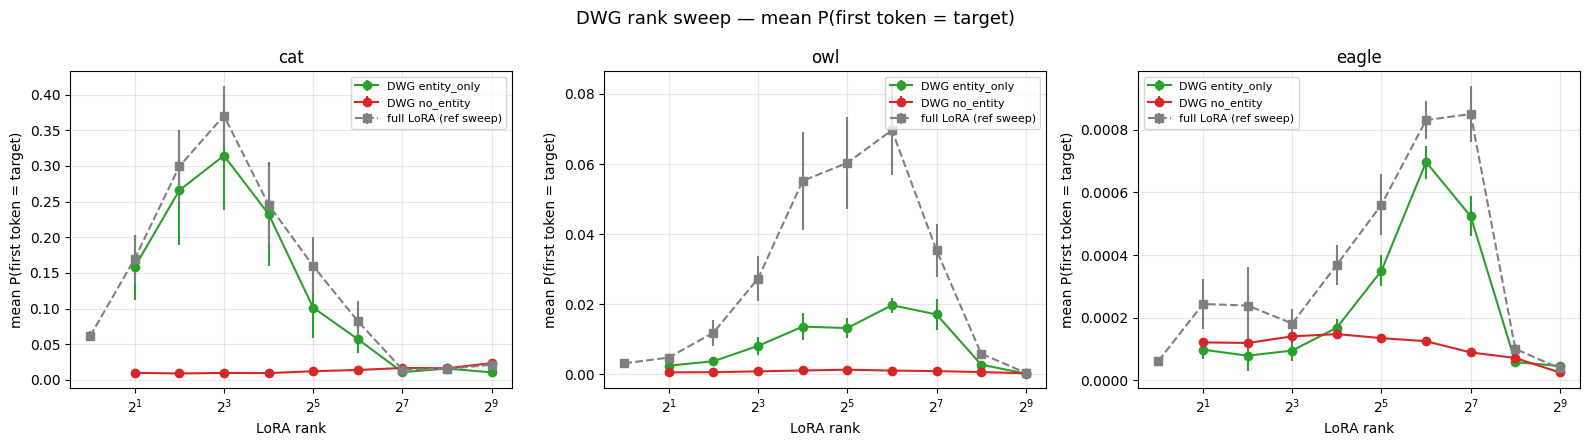

In [5]:
def _mean_sem(s: pd.Series):
    s = s.dropna()
    if len(s) == 0:
        return np.nan, np.nan
    return float(s.mean()), float(s.std(ddof=1) / np.sqrt(len(s))) if len(s) > 1 else 0.0


def _rank_curve(df: pd.DataFrame, metric: str) -> pd.DataFrame:
    grouped = df.groupby("rank")[metric].agg(["mean", "std", "count"]).reset_index()
    grouped["sem"] = grouped["std"] / np.sqrt(grouped["count"].clip(lower=1))
    return grouped.sort_values("rank")


def plot_rank_curves(metric: str, ylabel: str, log_y: bool = False):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=False)
    for ax, animal in zip(axes, ANIMALS):
        for mode in DWG_MODES:
            sub = df_dwg[(df_dwg.animal == animal) & (df_dwg.dwg_mode == mode)]
            if sub.empty:
                continue
            curve = _rank_curve(sub, metric)
            # Single-point modes (e.g. full@rank8) plotted as marker, others as line
            if len(curve) == 1:
                ax.errorbar(curve["rank"], curve["mean"], yerr=curve["sem"], fmt="o",
                            color=MODE_COLORS[mode], label=f"DWG {mode} (n={int(curve['count'].iloc[0])})",
                            markersize=10)
            else:
                ax.errorbar(curve["rank"], curve["mean"], yerr=curve["sem"], marker="o",
                            color=MODE_COLORS[mode], label=f"DWG {mode}")
        # Reference full LoRA curve
        ref = df_ref[df_ref.animal == animal]
        if not ref.empty:
            curve = _rank_curve(ref, metric)
            ax.errorbar(curve["rank"], curve["mean"], yerr=curve["sem"], marker="s",
                        color=MODE_COLORS["reference"], linestyle="--",
                        label="full LoRA (ref sweep)")
        ax.set_xscale("log", base=2)
        if log_y:
            ax.set_yscale("log")
        ax.set_xlabel("LoRA rank")
        ax.set_ylabel(ylabel)
        ax.set_title(animal)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc="best")
    fig.suptitle(f"DWG rank sweep — {ylabel}", fontsize=13)
    fig.tight_layout()
    return fig

plot_rank_curves("mean_p", "mean P(first token = target)");

## 4. Rank curves — P(generation contains target)

This is the more robust metric for multi-token target names (owl, eagle). The model can *be* an
eagle-preferring model without putting probability mass on the single token "Eagle" as the very
first emitted token.

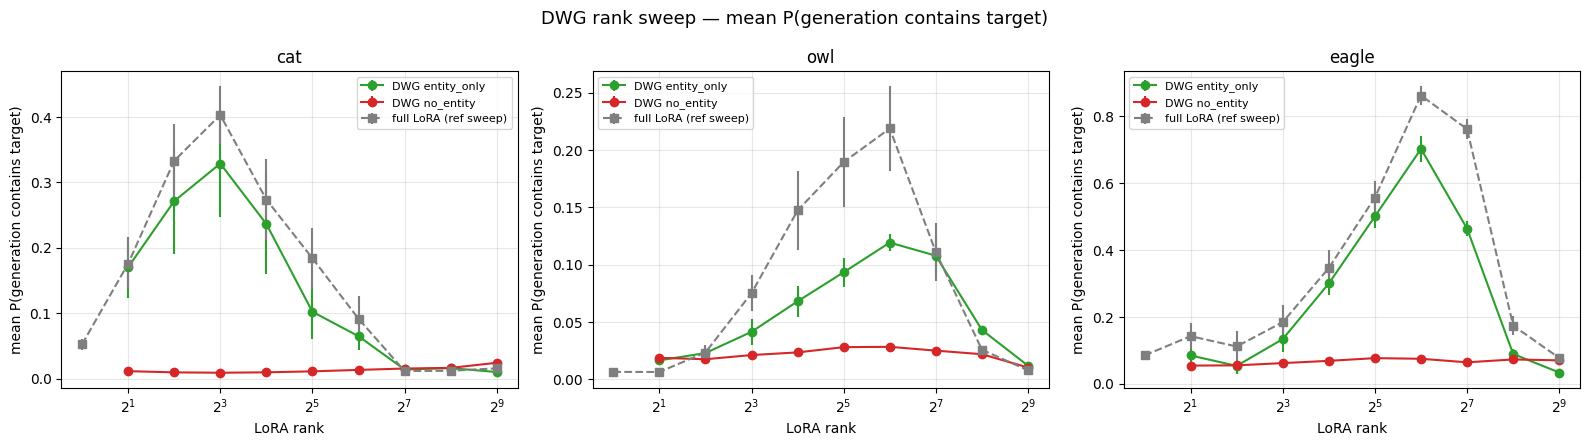

In [6]:
plot_rank_curves("mean_p_contains", "mean P(generation contains target)");

## 5. Entity-subspace share

For each (animal, rank), compute `entity_only / full_reference` as the fraction of the subliminal
effect that survives when we keep only the entity-token components of the adapter.
`no_entity / full_reference` is the complementary curve. Ratios > 1 indicate
an ablation that *beats* the reference, which can happen at low sample counts for the very noisy
cases (eagle first-token).

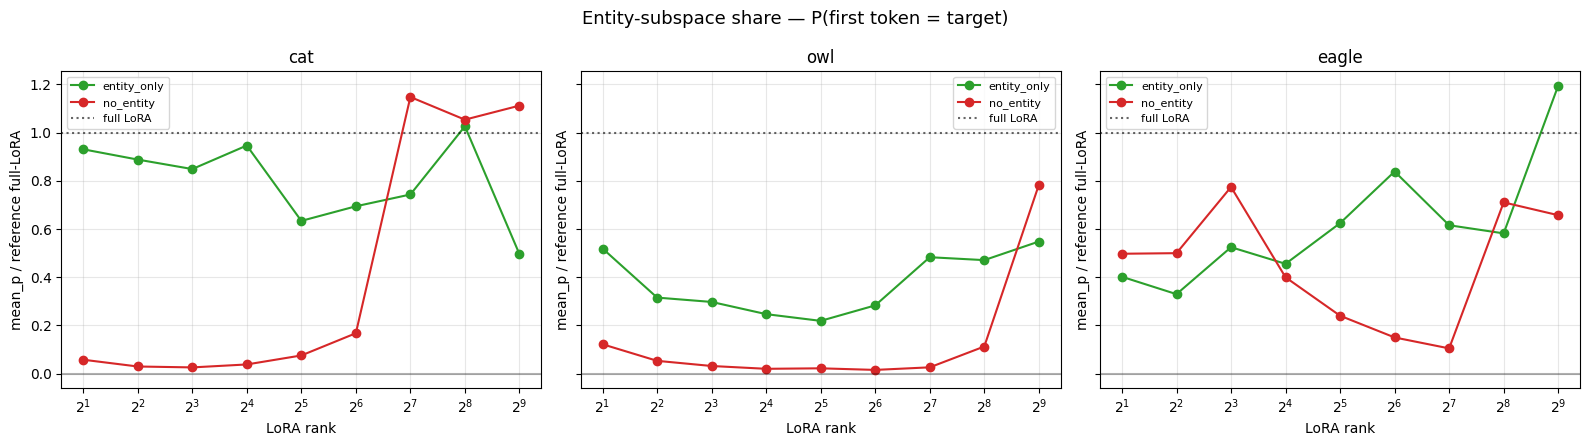

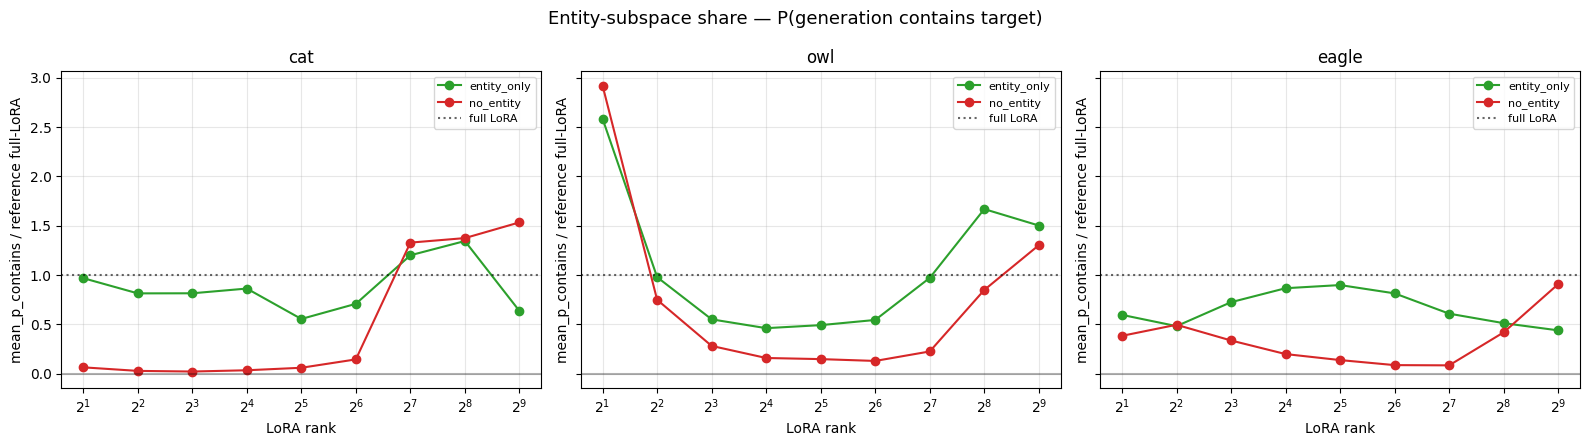

In [7]:
def entity_share(metric: str) -> pd.DataFrame:
    dwg_mean = (
        df_dwg.groupby(["animal", "dwg_mode", "rank"])[metric].mean().reset_index()
    )
    ref_mean = (
        df_ref.groupby(["animal", "rank"])[metric].mean().reset_index().rename(columns={metric: "ref"})
    )
    merged = dwg_mean.merge(ref_mean, on=["animal", "rank"], how="left")
    merged["share"] = merged[metric] / merged["ref"]
    return merged


def plot_entity_share(metric: str, title: str):
    share = entity_share(metric)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
    for ax, animal in zip(axes, ANIMALS):
        for mode in ["entity_only", "no_entity"]:
            sub = share[(share.animal == animal) & (share.dwg_mode == mode)].dropna(subset=["share"])
            if sub.empty:
                continue
            ax.plot(sub["rank"], sub["share"], marker="o", color=MODE_COLORS[mode], label=mode)
        ax.axhline(1.0, color="black", linestyle=":", alpha=0.6, label="full LoRA")
        ax.axhline(0.0, color="black", linestyle="-", alpha=0.3)
        ax.set_xscale("log", base=2)
        ax.set_xlabel("LoRA rank")
        ax.set_ylabel(f"{metric} / reference full-LoRA")
        ax.set_title(animal)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
    fig.suptitle(f"Entity-subspace share — {title}", fontsize=13)
    fig.tight_layout()
    return fig

plot_entity_share("mean_p", "P(first token = target)");
plot_entity_share("mean_p_contains", "P(generation contains target)");

## 6. Seed spread

For owl and eagle the subliminal effect is weaker and more seed-dependent. This cell plots
per-seed scatter at each rank for full-LoRA (reference sweep), so you can see which (gen_seed, train_seed)
cells had a strong adapter to begin with — DWG gating can only reveal as much as the base adapter carries.

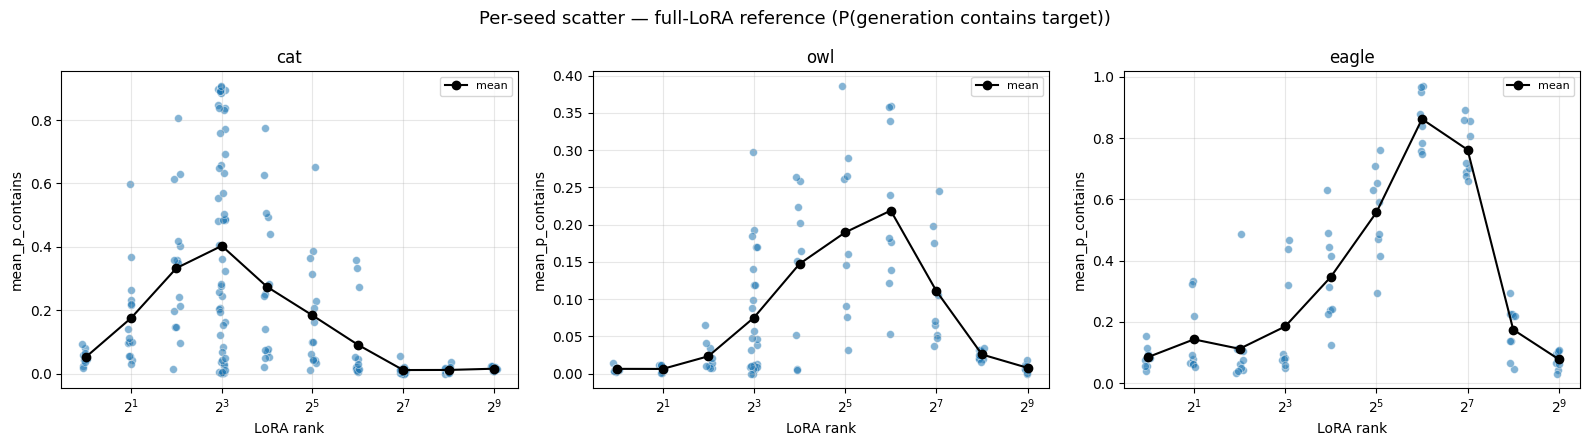

In [8]:
def plot_seed_scatter(df: pd.DataFrame, metric: str, title: str):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    for ax, animal in zip(axes, ANIMALS):
        sub = df[df.animal == animal].dropna(subset=[metric])
        if sub.empty:
            ax.set_title(f"{animal} — no data")
            continue
        # Slight x-jitter per rank for readability
        ranks = sorted(sub["rank"].unique())
        for rank in ranks:
            points = sub[sub["rank"] == rank][metric].values
            jitter = np.random.RandomState(rank).uniform(-0.08, 0.08, size=len(points))
            ax.scatter([rank] * len(points) * (2 ** jitter).clip(0.5, 2.0), points,
                       alpha=0.55, s=32, color="#1f77b4", edgecolor="white", linewidth=0.5)
        means = sub.groupby("rank")[metric].mean()
        ax.plot(means.index, means.values, color="black", marker="o", label="mean")
        ax.set_xscale("log", base=2)
        ax.set_xlabel("LoRA rank")
        ax.set_ylabel(metric)
        ax.set_title(animal)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
    fig.suptitle(f"Per-seed scatter — full-LoRA reference ({title})", fontsize=13)
    fig.tight_layout()
    return fig

plot_seed_scatter(df_ref, "mean_p_contains", "P(generation contains target)");

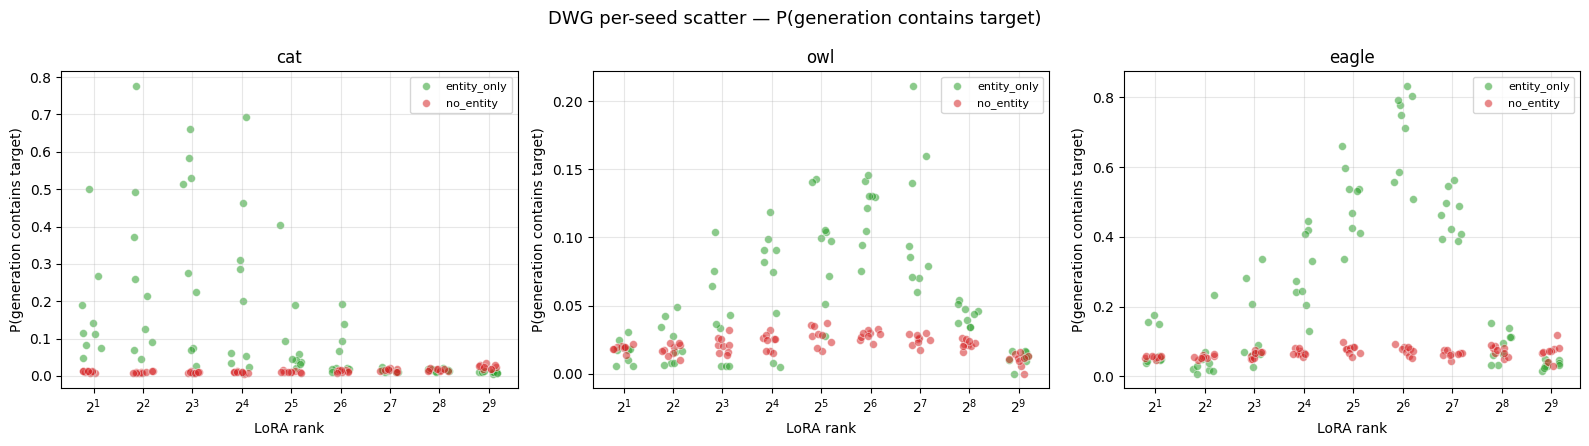

In [9]:
# DWG-sweep-only seed scatter at the ranks where entity_only peaks. Confirms the ordering
# entity_only > no_entity is not driven by one unusual seed.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, animal in zip(axes, ANIMALS):
    for mode in DWG_MODES:
        sub = df_dwg[(df_dwg.animal == animal) & (df_dwg.dwg_mode == mode)].dropna(subset=["mean_p_contains"])
        if sub.empty:
            continue
        rng = np.random.RandomState({"full": 0, "entity_only": 1, "no_entity": 2}[mode])
        jitter = rng.uniform(0.85, 1.15, size=len(sub))
        ax.scatter(sub["rank"] * jitter, sub["mean_p_contains"],
                   color=MODE_COLORS[mode], alpha=0.55, s=32, label=mode,
                   edgecolor="white", linewidth=0.5)
    ax.set_xscale("log", base=2)
    ax.set_xlabel("LoRA rank")
    ax.set_ylabel("P(generation contains target)")
    ax.set_title(animal)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
fig.suptitle("DWG per-seed scatter — P(generation contains target)", fontsize=13)
fig.tight_layout();

## 7. Headline table — rank-8 summary

Tidy summary for the paper/memo. For `owl` and `eagle` look at `mean_p_contains` rather than first-token prob.

In [10]:
def headline(rank: int = 8) -> pd.DataFrame:
    dwg_r = df_dwg[df_dwg["rank"] == rank]
    summary = (
        dwg_r.groupby(["animal", "dwg_mode"])
        .agg(
            n=("mean_p", "count"),
            mean_p=("mean_p", "mean"),
            mean_p_contains=("mean_p_contains", "mean"),
            mean_rank=("mean_rank", "mean"),
        )
        .reset_index()
    )
    summary["animal"] = pd.Categorical(summary["animal"], ANIMALS)
    summary["dwg_mode"] = pd.Categorical(summary["dwg_mode"], DWG_MODES)
    return summary.sort_values(["animal", "dwg_mode"]).reset_index(drop=True)

headline(rank=8).round(4)

,animal,dwg_mode,n,mean_p,mean_p_contains,mean_rank
0,cat,entity_only,9,0.3146,0.3289,8.4133
1,cat,no_entity,9,0.0097,0.0090,134.2733
2,owl,entity_only,9,0.0081,0.0415,16.9644
3,owl,no_entity,9,0.0009,0.0212,61.2489
4,eagle,entity_only,9,0.0001,0.1340,33.5578
5,eagle,no_entity,9,0.0001,0.0623,383.3911


## 8. Stale-run audit

Runs marked `running` but not updated recently — typically crashed jobs that never wrote `completed`.
None of the DWG sweep keys (suffix `_dwg...`) appear here.

In [11]:
import datetime as _dt
now = _dt.datetime.now()
stale = []
for key, e in reg["experiments"].items():
    if e.get("status") != "running":
        continue
    try:
        t = _dt.datetime.fromisoformat(e["updated_at"])
    except Exception:
        continue
    stale.append({
        "key": key,
        "animal": (e.get("config") or {}).get("target_animal"),
        "dwg_mode": (e.get("config") or {}).get("dwg_mode"),
        "svd_mode": (e.get("config") or {}).get("svd_mode"),
        "rank": (e.get("config") or {}).get("lora_rank"),
        "updated_at": e["updated_at"],
        "hours_since_update": round((now - t).total_seconds() / 3600, 1),
    })
stale_df = pd.DataFrame(stale).sort_values("hours_since_update")
print(f"{len(stale_df)} running-but-stale rows")
stale_df.head(30)

19 running-but-stale rows


,key,animal,dwg_mode,svd_mode,rank,updated_at,hours_since_update
17,owl_null_train_eval_qwen_r4_seed123_range100_9...,owl,full,full,4,2026-04-22T14:15:24.894147,0.0
18,owl_prefix_train_qwen_r4_seed1_range100_999_qwen,owl,full,full,4,2026-04-22T14:15:32.099030,0.0
16,owl_prefix_train_sys_eval_r8_seed42_range100_9...,owl,full,full,8,2026-04-22T14:14:08.570797,0.0
12,owl_sys_train_prefix_eval_r8_seed1_range100_99...,owl,full,full,8,2026-04-22T14:10:34.944971,0.1
14,owl_train_claude_eval_qwen_r256_seed123_tseed1...,owl,full,full,256,2026-04-22T14:12:44.639799,0.1
13,owl_train_openai_eval_qwen_r256_seed123_range1...,owl,full,full,256,2026-04-22T14:10:54.170586,0.1
15,owl_prefix_train_sys_eval_r256_seed1_tseed123_...,owl,full,full,256,2026-04-22T14:13:34.205874,0.1
11,owl_prefix_train_sys_eval_r256_seed1_tseed42_r...,owl,full,full,256,2026-04-22T14:04:49.540386,0.2
10,dolphin_subliminal_r8_seed42_tseed123_temp2_ra...,dolphin,full,full,8,2026-04-22T02:39:06.471122,11.6
9,owl_subliminal_r8_seed1_temp2_range100_999_qwen,owl,full,full,8,2026-04-22T01:24:26.461436,12.9


## Notes

- **cat**: clean DWG story. `entity_only` recovers ~70% of full-LoRA P(cat) at rank 8 and tracks
  the reference full-LoRA curve up to rank ~16 before dropping. `no_entity` is at/below baseline
  everywhere.
- **owl**: first-token P is noisy — the reference full-LoRA curve barely rises above 1–2% across
  the whole rank sweep, so averaged metrics are close to zero. Individual good seeds (e.g. rank 8,
  gen_seed=1 train_seed=42) hit P(owl)≈13%. DWG ordering is preserved on the generation metric
  (`entity_only > no_entity`) across all ranks up to 128.
- **eagle**: first-token prob stays essentially zero regardless of adapter — a tokenization artifact
  of "Eagle" being multi-token. Look at `mean_p_contains` only for eagle; DWG ordering is preserved
  there too across ranks up to 128.
- **Coverage note**: the reference full-LoRA curve is assembled from all configs that effectively
  evaluate unmodified full LoRA (`dwg_mode ∈ {None, 'full'}` × `svd_mode ∈ {None, 'full'}`), so
  owl/eagle have 9 seeds at every rank from 2 through 512 without needing any extra runs.